# TCGA

The Cancer Genome Atlas (TCGA) is a comprehensive resource that catalogs genomic alterations across 33 different human cancers. Unlike cell lines, TCGA analyzes primary tumor samples directly from patients, providing a detailed view of the tumor's molecular landscape within its native tissue environment. The dataset includes genomic, epigenomic, transcriptomic, and proteomic data but for our analysis we focus on genomic data, in particular on mRNA data and mutations data.

## Contents of the notebook
In this notebook, we analyse and prepare the downloaded data for use in classifier training. The data was downloaded from cBioportal by querying TCGA. We then selected a subset of cancer studies, downloading the following files for each study:

data_mutations.txt : Dataframe containing information of all the mutated genes in the samples;
data_mrna_seq_rpkm.txt: expression data with samples as columns and genes as rows;

We analyse samples and genes to filter outliers and understand the distribution. We then visualise the data using dimensionality reduction techniques. Finally, we prepare the dataset that will be used to build the classifiers.

In [32]:
import pandas as pd 
import numpy as np 
import os 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.manifold import TSNE
from scipy.stats import skew, kurtosis
from sklearn.decomposition import PCA
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()

## Auxiliary Functions

In [2]:
def plot_violin_metrics(data, axis):

    if axis == 1:

        total_counts_genes = data.sum(axis=1).reset_index(drop=True)
        mean_values_genes = data.mean(axis=1).reset_index(drop=True)
        median_values_genes = data.median(axis=1).reset_index(drop=True)
        std_values_genes = data.std(axis = 1).reset_index(drop = True)
        cv_values_genes = std_values_genes /mean_values_genes
        total_features_genes = data.astype(bool).sum(axis = 1).reset_index(drop = True)

        # Set up subplots
        fig, ax = plt.subplots(1, 6, figsize=(25, 12))

        # Total Counts per Gene
        sns.violinplot(y=total_counts_genes, ax=ax[0], color='firebrick')
        ax[0].set_title('Total Counts Across Genes')
        ax[0].set_xlabel('')
        ax[0].grid(True)

        # Mean Counts per Gene
        sns.violinplot(y=mean_values_genes, ax=ax[1], color='steelblue')
        ax[1].set_title('Mean Counts Across Genes')
        ax[1].set_xlabel('')
        ax[1].grid(True)

        # Median Counts per Gene
        sns.violinplot(y=median_values_genes, ax=ax[2], color='orange')
        ax[2].set_title('Median Counts Across Genes')
        ax[2].set_xlabel('')
        ax[2].grid(True)

        # Std values per Gene
        sns.violinplot(y=std_values_genes, ax=ax[3], color='darkgreen')
        ax[3].set_title('Standard deviation across Genes')
        ax[3].set_xlabel('')
        ax[3].grid(True)

        # Coefficeint of variation std/mean per Gene
        sns.violinplot(y=cv_values_genes, ax=ax[4], color='indigo')
        ax[4].set_title('Coefficient of variation across Genes')
        ax[4].set_xlabel('')
        ax[4].grid(True)

        # Total Features per Gene
        sns.violinplot(y=total_features_genes, ax=ax[5], color='silver')
        ax[5].set_title('Total Features Across Genes')
        ax[5].set_xlabel('')
        ax[5].grid(True)

        plt.tight_layout()
        plt.show()

        # Print differences between extremes
        print(f'Max_total_count ({total_counts_genes.max()}) - Min_total_count ({total_counts_genes.min()}) = {total_counts_genes.max() - total_counts_genes.min()}')
        print(f'Max_mean_count ({mean_values_genes.max()}) - Min_mean_count ({mean_values_genes.min()}) = {mean_values_genes.max() - mean_values_genes.min()}')
        print(f'Max_median_count ({median_values_genes.max()}) - Min_median_count ({median_values_genes.min()}) = {median_values_genes.max() - median_values_genes.min()}')
        print(f'Max std  ({std_values_genes.max()}) - Min std ({std_values_genes.min()}) = {std_values_genes.max() - std_values_genes.min()}')
        print(f'Max cv  ({cv_values_genes.max()}) - Min cv ({cv_values_genes.min()}) = {cv_values_genes.max() - cv_values_genes.min()}')
        print(f'Max feature count  ({total_features_genes.max()}) - Min feature count ({total_features_genes.min()}) = {total_features_genes.max() - total_features_genes.min()}')

    
    if axis == 0:

        total_counts = data.sum(axis=0).reset_index(drop=True)
        mean_values = data.mean(axis=0).reset_index(drop=True)
        std_values = data.std(axis = 0).reset_index(drop=True)
        median_values = data.median(axis=0).reset_index(drop=True)
        cv_values = std_values/mean_values
        total_features = data.astype(bool).sum(axis = 0).reset_index(drop = True)


        # Set up the figure with 3 subplots
        fig, ax = plt.subplots(1, 6, figsize=(25, 12))

        # Total Counts
        sns.violinplot(y=total_counts, ax=ax[0], color='firebrick')
        ax[0].set_title('Total Counts Across Samples')
        ax[0].set_xlabel('')
        ax[0].grid(True)

        # Mean Values
        sns.violinplot(y=mean_values, ax=ax[1], color='steelblue')
        ax[1].set_title('Mean Across Samples')
        ax[1].set_xlabel('')
        ax[1].grid(True)

        # Median Values
        sns.violinplot(y=median_values, ax=ax[2], color='orange')
        ax[2].set_title('Median Samples')
        ax[2].set_xlabel('')
        ax[2].grid(True)

        # Std values
        sns.violinplot(y=std_values, ax=ax[3], color='darkgreen')
        ax[3].set_title('Standard deviation Samples')
        ax[3].set_xlabel('')
        ax[3].grid(True)

        # Coefficeint of variation std/mean per sample
        sns.violinplot(y=cv_values, ax=ax[4], color='indigo')
        ax[4].set_title('Coefficient of variation across Samples')
        ax[4].set_xlabel('')
        ax[4].grid(True)

        # Total features 
        sns.violinplot(y=total_features, ax=ax[5], color='silver')
        ax[5].set_title('Total features across Samples')
        ax[5].set_xlabel('')
        ax[5].grid(True)


        plt.tight_layout()
        plt.show()

        # Print differences between extremes
        print(f'Max_total_count ({total_counts.max()}) - Min_total_count ({total_counts.min()}) = {total_counts.max() - total_counts.min()}')
        print(f'Max_mean_count ({mean_values.max()}) - Min_mean_count ({mean_values.min()}) = {mean_values.max() - mean_values.min()}')
        print(f'Max_median_count ({median_values.max()}) - Min_median_count ({median_values.min()}) = {median_values.max() - median_values.min()}')
        print(f'Max_std ({std_values.max()}) - Min_std ({std_values.min()}) = {std_values.max() - std_values.min()}')
        print(f'Max CV ({cv_values.max()}) - Min CV ({cv_values.min()}) = {cv_values.max() - cv_values.min()}')
        print(f'Max feature count  ({total_features.max()}) - Min feature count ({total_features.min()}) = {total_features.max() - total_features.min()}')


def plot_skewness_kurtosis(data,axis):

    if axis == 0:
        # Compute skewness and kurtosis per sample (column-wise)
        skewness_per_sample = data.apply(skew, axis=0)
        kurtosis_per_sample = data.apply(kurtosis, axis=0)

        # Plot skewness
        plt.figure(figsize=(14, 5))
        plt.subplot(1, 2, 1)
        plt.bar(range(len(skewness_per_sample)), skewness_per_sample.values, color='mediumpurple')
        plt.title("Skewness of Expression per Sample")
        plt.xlabel("Sample Index")
        plt.ylabel("Skewness")
        plt.grid(True)

        # Plot kurtosis
        plt.subplot(1, 2, 2)
        plt.bar(range(len(kurtosis_per_sample)), kurtosis_per_sample.values, color='darkorange')
        plt.title("Excess Kurtosis per Sample")
        plt.xlabel("Sample Index")
        plt.ylabel("Kurtosis")
        plt.grid(True)

        plt.tight_layout()
        plt.show()
    if axis == 1:
        # Compute skewness and kurtosis per sample (column-wise)
        skewness_per_gene = data.apply(skew, axis=1)
        kurtosis_per_gene = data.apply(kurtosis, axis=1)
        
        # Plot skewness
        plt.figure(figsize=(14, 5))
        plt.subplot(1, 2, 1)
        plt.bar(range(len(skewness_per_gene)), skewness_per_gene.values, color='mediumpurple')
        plt.title("Skewness of Expression per Gene")
        plt.xlabel("Sample Index")
        plt.ylabel("Skewness")
        plt.grid(True)
        
        # Plot kurtosis
        plt.subplot(1, 2, 2)
        plt.bar(range(len(kurtosis_per_gene)), kurtosis_per_gene.values, color='darkorange')
        plt.title("Excess Kurtosis per Gene")
        plt.xlabel("Sample Index")
        plt.ylabel("Kurtosis")
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()

def heatmap_plot(title,data,samples):
    plt.title(title)
    sns.heatmap(data.loc[:, samples].corr(), cmap = 'viridis', fmt ='.01f');
    print(f"Number of samples plotted: {(len(samples),len(samples))}")


def plot_PCA_tsne(data_ordered,mutated_samples,non_mutated_samples, title):

    mutation_status = ['Mutated']*len(mutated_samples) + ['Non_Mutated']*len(non_mutated_samples)
    label_map = {'Mutated': 0, 'Non_Mutated': 1}
    color_values = [label_map[label] for label in mutation_status]

    # Perform PCA (reduce to 2 components)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(data_ordered.T.to_numpy())

    # Perform t-SNE (reduce to 2 components)
    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(data_ordered.T.to_numpy())

    # Plot PCA
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.scatter(pca_result[:, 0], pca_result[:, 1], c=color_values, cmap='viridis')
    plt.title('PCA: Mutated vs Non-Mutated')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True)
    plt.legend(['Mutated', 'Non_Mutated'], loc='upper right')

    # Plot t-SNE
    plt.subplot(1, 2, 2)
    plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=color_values, cmap='viridis')
    plt.title('t-SNE: Mutated vs Non-Mutated')
    plt.xlabel('tSNE1')
    plt.ylabel('tSNE2')
    plt.grid(True)
    plt.legend(['Mutated', 'Non_Mutated'], loc='upper right')


    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_MT_percent_violinplot(data):

    sum_df = data.sum(axis = 0)
    mt_sum_df = data.loc[data.index[data.index.str.startswith("MT-")]].sum(axis=0)
    mt_percentage = (mt_sum_df / sum_df) * 100

    mt_df = pd.DataFrame({'Sample': mt_percentage.index, 'MT_Percent': mt_percentage.values})

    # Plot violin plot
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=mt_df, y='MT_Percent', color='skyblue')
    plt.title('Violin Plot of Mitochondrial Gene Expression Percentage per Sample')
    plt.ylabel('Mitochondrial % of Total RPKM')
    plt.xlabel('')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## TCGA data
### Description

In order to have a relevant number of samples, we have selected a number of different cancer types, all belonging to the same study (PanCancer Atlas). We have included cancers with a high rate of TP53 somatic mutations (38%-50% in ovarian, colorectal and lung cancers), as well as cancers with a low rate of TP53 somatic mutations (5% in melanoma). All the mRNA data from all the cancers was normalised in the same way (batch normalised from Illumina HiSeq_RNASeqV2).
In this section of the notebook, we extract and concatenate the mRNA and mutation data for exploration.

In [5]:
result_list = [] # to collect resulting dataframes 

df = pd.read_table('/Users/andreafabbricatore/Desktop/mac_bocconi/MAI/year 1/semester 2/ML Lab/AILAB/DATA/tcga/data_mutations.txt', delimiter='\t', comment='#')

df = df[df['Hugo_Symbol'] == 'TP53']

# Keeping only columns that are relevat for our study
final_df = df[['Hugo_Symbol', 'Tumor_Sample_Barcode','Variant_Classification','Variant_Type']]   
#final_df['Tumor_Name'] = ''

final_df.to_csv('../DATA/tcga/mutation_data_complete.csv', index=False)


file_path = '/Users/andreafabbricatore/Desktop/mac_bocconi/MAI/year 1/semester 2/ML Lab/AILAB/DATA/tcga/data_mrna_seq_fpkm.txt'

df = pd.read_csv(file_path, sep='\t', index_col=0)
df.index = df.index.str.strip()

# If there are multiple rows concerning the same gene we average the results 
df = df.groupby(df.index).mean()

df.to_csv('../DATA/tcga/mrna_data.csv')


In [6]:
# Visualize all different types of variant classification 
print('Variant classification unique values: ',final_df['Variant_Classification'].unique().tolist())
print('Variant type unique values: ',final_df['Variant_Type'].unique().tolist() )

Variant classification unique values:  ['Nonsense_Mutation', 'Missense_Mutation', 'In_Frame_Del', 'Frame_Shift_Del', 'Splice_Site', 'Frame_Shift_Ins', 'Splice_Region', 'In_Frame_Ins', 'Silent']
Variant type unique values:  ['SNP', 'DEL', 'INS', 'DNP']


Now that we have merged all the mRNA data into one file and all the mutation data into another, we can create the final datasets on which to perform our analysis.

In [9]:
import pandas as pd

# --------- Load and Clean mRNA Data ---------
mRNA_path = '../DATA/tcga/mrna_data.csv'

# Load expression data
mRNA_data = pd.read_csv(mRNA_path)

# Set gene names as index
mRNA_data.set_index('Hugo_Symbol', inplace=True)

# Drop the first column if it's repeated index or metadata
if mRNA_data.columns[0] == mRNA_data.columns.name:
    mRNA_data = mRNA_data[mRNA_data.columns[1:]]

# Drop samples (columns) with any missing values
if mRNA_data.isna().sum().any():
    print("There are NaN values in mRNA data. Dropping them...")
    mRNA_data = mRNA_data.dropna(axis=1)

print("mRNA data shape after cleaning:", mRNA_data.shape)

# --------- Load and Filter Mutation Data (TP53) ---------
mut_path = '../DATA/tcga/mutation_data_complete.csv'

# Load mutation dataset
mut_data = pd.read_csv(mut_path)

# Keep only sample barcode and mutation type
mut_data = mut_data[['Tumor_Sample_Barcode', 'Variant_Type']]
mut_data.set_index('Tumor_Sample_Barcode', inplace=True)

# Remove samples with inconsistent mutation annotations (e.g., multiple variant types)
variant_check = mut_data.groupby(mut_data.index)["Variant_Type"].nunique()
consistent_samples = variant_check[variant_check == 1].index
inconsistent_samples = variant_check[variant_check != 1].index

mut_data = mut_data.loc[consistent_samples]

# Drop inconsistent samples from mRNA data if present
mRNA_data = mRNA_data.drop(columns=[sample for sample in inconsistent_samples if sample in mRNA_data.columns])

# Remove duplicate sample entries (same Variant_Type) — keep the first occurrence
mut_data = mut_data[~mut_data.index.duplicated(keep='first')]

# --------- Add Wild-Type (WT) Labels ---------
all_samples = set(mRNA_data.columns)
mutated_samples = set(mut_data.index)
wt_samples = all_samples - mutated_samples

# Create WT labels for non-mutated samples
wt_df = pd.DataFrame(index=list(wt_samples))
wt_df['Variant_Type'] = 'WT'

# Combine WT and Mutated samples into one mutation dataframe
mut_data = pd.concat([mut_data, wt_df])

# Align order with mRNA columns
mut_data = mut_data.loc[mRNA_data.columns]

# --------- Final Summary ---------
print("Final sample counts by mutation type:")
print(mut_data['Variant_Type'].value_counts())

# Now you have:
# - `mRNA_data`: gene expression (genes x samples)
# - `mut_data`: mutation status (samples x 1)


mRNA data shape after cleaning: (55851, 1210)
Final sample counts by mutation type:
Variant_Type
WT     803
SNP    331
DEL     46
INS     18
DNP      5
Name: count, dtype: int64


There are Nan values
Nan values removed

In [11]:
# We want to take samples for which we have both the mrna expression and the mutation

common = list(set(mRNA_data.columns) & set(mut_data.index))
mRNA_data= mRNA_data[common] # This contains mRNA data
merged_mutation = mut_data.loc[common] # This contains mutation type

merged_mutation.to_csv('../DATA/tcga/final_mutation_data.csv',index=True)
mRNA_data.to_csv('../DATA/tcga/final_mrna_data.csv',index=True)

Now I want to reduce the dimensionality of the data. In order to do so I will use a biological cue: I will consider in the expression data only the expressions related to TP53 target genes and see if these vary significantly between mutated and non mutated data. If so then I can build my classifier only considering the expression of these genes.

In [12]:
tp53_targets = [
    'CDKN1A', 'ABCA12', 'NTPCR', 'PGPEP1', 'RNF19B', 'LCE1E', 'EPN3', 'SCN4B', 'ARVCF', 'FCHO2',
    'PANK2', 'TMEM8B', 'RRM2B', 'ANKRA2', 'ORAI3', 'PLCL2', 'SAC3D1', 'LIMK2', 'FBXO32', 'SCRIB',
    'BHLHE40', 'FCHSD2', 'PAQR7', 'TP53', 'MDM2', 'CCNG1', 'PRKAB1', 'PMAIP1', 'SYTL1', 'LRP1',
    'FHL2', 'SEMA3B', 'BMP7', 'FLRT2', 'PCBP4', 'TP53I11', 'SUSD6', 'CYFIP2', 'PTP4A1', 'PRDM1',
    'TNFRSF10A', 'MCC', 'HES2', 'SLC25A45', 'BORCS7', 'GBE1', 'PERP', 'TRAK1', 'GDF15', 'DRAM1',
    'SESN2', 'RAP2B', 'TNFRSF10D', 'NUPR1', 'KCNN4', 'SLC44A5', 'BTBD10', 'GPC1', 'PLLP', 'TRIP6',
    'BTG2', 'FBXO22', 'SLC30A1', 'RRAD', 'TSPAN11', 'PARD6G', 'KLHDC7A', 'SLC4A11', 'BTG3', 'HES1',
    'POU3F1', 'TSGA10', 'DDB2', 'ISCU', 'SPATA18', 'ZNF219', 'VWCE', 'PHPT1', 'LMNA', 'SLC9A1',
    'C17orf89', 'HRAS', 'PPFIBP1', 'UNC5B', 'GADD45A', 'PHLDA3', 'TGFA', 'ZNF337', 'DDIT4', 'PIDD1',
    'MLF2', 'STAT3', 'CAPN2', 'HSD17B3', 'PPM1J', 'UQCC1', 'PLK3', 'SERPINB5', 'TLR3', 'ACTA2',
    'RAD51C', 'PML', 'MR1', 'STK17A', 'CASP6', 'ICOSLG', 'PPP4R3A', 'VDR', 'TIGAR', 'SERTAD1',
    'TM7SF3', 'EDN2', 'SERPINE1', 'PTPRE', 'MYO6', 'STX6', 'CATSPERG', 'IGFBP7', 'PTAFR', 'YPEL3',
    'RPS27L', 'TRAF4', 'TMEM68', 'ALOX5', 'TNFAIP8', 'PVRL4', 'NEFL', 'TP73', 'CAV1', 'IL1B',
    'RALGDS', 'ZNF195', 'TNFRSF10B', 'TRIM22', 'WDR63', 'ARHGEF3', 'TSKU', 'RETSAT', 'NKAIN4',
    'TRIM32', 'CCNK', 'ISYNA1', 'RBM38', 'ZNF385A', 'TRIAP1', 'CES2', 'ZNF561', 'CERS5', 'PCNA',
    'REV3L', 'PCLO', 'TRIM38', 'CFLAR', 'JAG1', 'RGL1', 'ZNF488', 'ZMAT3', 'CMBL', 'ZNF79',
    'DDR1', 'ACYP2', 'RNASE7', 'PDE4C', 'TRIM5', 'CGB7', 'KRT8', 'RGS20', 'BAX', 'FBXW7',
    'ASCC3', 'DHRS3', 'APAF1', 'SFN', 'PGAP1', 'TYMSOS', 'CHST14', 'KSR1', 'RHOC', 'PGF',
    'HSPA4L', 'ACER2', 'DUSP14', 'APOBEC3H', 'TNFRSF10C', 'PLCXD2', 'AKAP9', 'COBLL1', 'LACC1',
    'RPS19', 'POLH', 'KITLG', 'ANXA4', 'E2F7', 'BCL2L1', 'TRIML2', 'PLEKHF1', 'CCDC51', 'CPEB2',
    'LPXN', 'SARS', 'PPM1D', 'SLC12A4', 'APOBEC3C', 'EPS8L2', 'BCL6', 'VCAN', 'PLTP', 'CDH8',
    'CPSF4', 'LRPAP1', 'SCIN', 'SULF2', 'ATF3', 'ASTN2', 'FAM210B', 'BLCAP', 'ADCK3', 'PLXNB1',
    'DUSP11', 'DNAJB2', 'MFAP3L', 'SCN3B', 'XPC', 'BBC3', 'CD82', 'GLS2', 'C17orf82', 'AK3',
    'PLXNB2', 'GCC2', 'DOCK8', 'MKNK2', 'SDC4', 'AEN', 'CCDC90B', 'CDIP1', 'GPX1', 'COL7A1',
    'ALDH1A3', 'PRKAB2', 'METTL8', 'DUSP5', 'MON2', 'SDPR', 'BLOC1S2', 'DYRK3', 'CPE', 'GRHL3',
    'CPEB4', 'BBS2', 'PRKX', 'PPP1R3C', 'DUSP7', 'MRPL49', 'SMAD3', 'FAS', 'EDA2R', 'CSF1',
    'HHAT', 'CSNK1G1', 'BTG1', 'PRODH', 'STEAP3', 'EBI3', 'MYBPHL', 'SNX2', 'GPR87', 'EPHA2',
    'DCP1B', 'IGDCC4', 'DGKA', 'CEL', 'PTPRU', 'ABHD4', 'EFNB1', 'MYLK', 'SOCS4', 'NINJ1',
    'FAM13C', 'ENC1', 'IKBIP', 'FAM49A', 'CLCA2', 'RGMA', 'ABTB2', 'EI24', 'MYOF', 'TAB3',
    'PLK2', 'FAM198B', 'FOSL1', 'LAPTM5', 'FAM84B', 'CLDN1', 'RGS16', 'ADGRG1', 'EML2', 'NFKBIA',
    'TCAIM', 'PSTPIP2', 'FAM212B', 'FUCA1', 'MAST4', 'GNAI1', 'CLP1', 'RND3', 'AIFM2', 'ENPP2',
    'NHLH2', 'TEP1', 'SESN1', 'FDXR', 'IER5', 'MICALL1', 'INPP1', 'CROT', 'RNF144B', 'AMOTL1',
    'ETV7', 'NLRP1', 'TET2', 'TP53I3', 'LIF', 'PADI4', 'NOTCH1', 'ITGA3', 'CYP4F3', 'S100A2',
    'AMZ2', 'FAM196A', 'NYNRIN', 'TEX9', 'TP53INP1', 'NADSYN1', 'PANK1', 'RABGGTA', 'KRT15',
    'DAPK1', 'SCN2A', 'ARC', 'FAM98C', 'P3H2', 'TMEM63B'
]

# Get the list of genes present in mRNA_data
genes_in_data = mRNA_data.index.tolist()

#Filter the TP53 target genes to include only the ones in the data
tp53_targets_final=list(set(tp53_targets).intersection(genes_in_data))

# Filter the mRNA expression to keep only target genes
mRNA_data_tp53_targets = mRNA_data.loc[tp53_targets_final]

print("Number of genes in the filtered gene expression data:", len(mRNA_data_tp53_targets))

# Now I want to separate samples based on mutation status: 
mutated_samples = merged_mutation[merged_mutation['Variant_Type'].isin(['DEL', 'SNP', 'INS'])].index
non_mutated_samples = merged_mutation[merged_mutation['Variant_Type'] == 'WT'].index

# Extract gene expression for two dataframes based on mutation status
# Since the sample_ids are columns in mRNA_data, we filter by column names
mutated_expression = mRNA_data[mutated_samples]
non_mutated_expression = mRNA_data[non_mutated_samples]

# Check the size of the filtered data
print(f"Mutated samples shape: {mutated_expression.shape}")
print(f"Non-mutated samples shape: {non_mutated_expression.shape}")

Number of genes in the filtered gene expression data: 335
Mutated samples shape: (55851, 395)
Non-mutated samples shape: (55851, 803)


## Sample analysis

In [13]:
# Shape of mRNA
print(f'Number of genes: {len(mRNA_data.index)}\nNumber of samples: {len(mRNA_data.columns)}')
print(f'Zero entries: {(mRNA_data == 0).sum().sum()}') 

Number of genes: 55851
Number of samples: 1203
Zero entries: 28785531


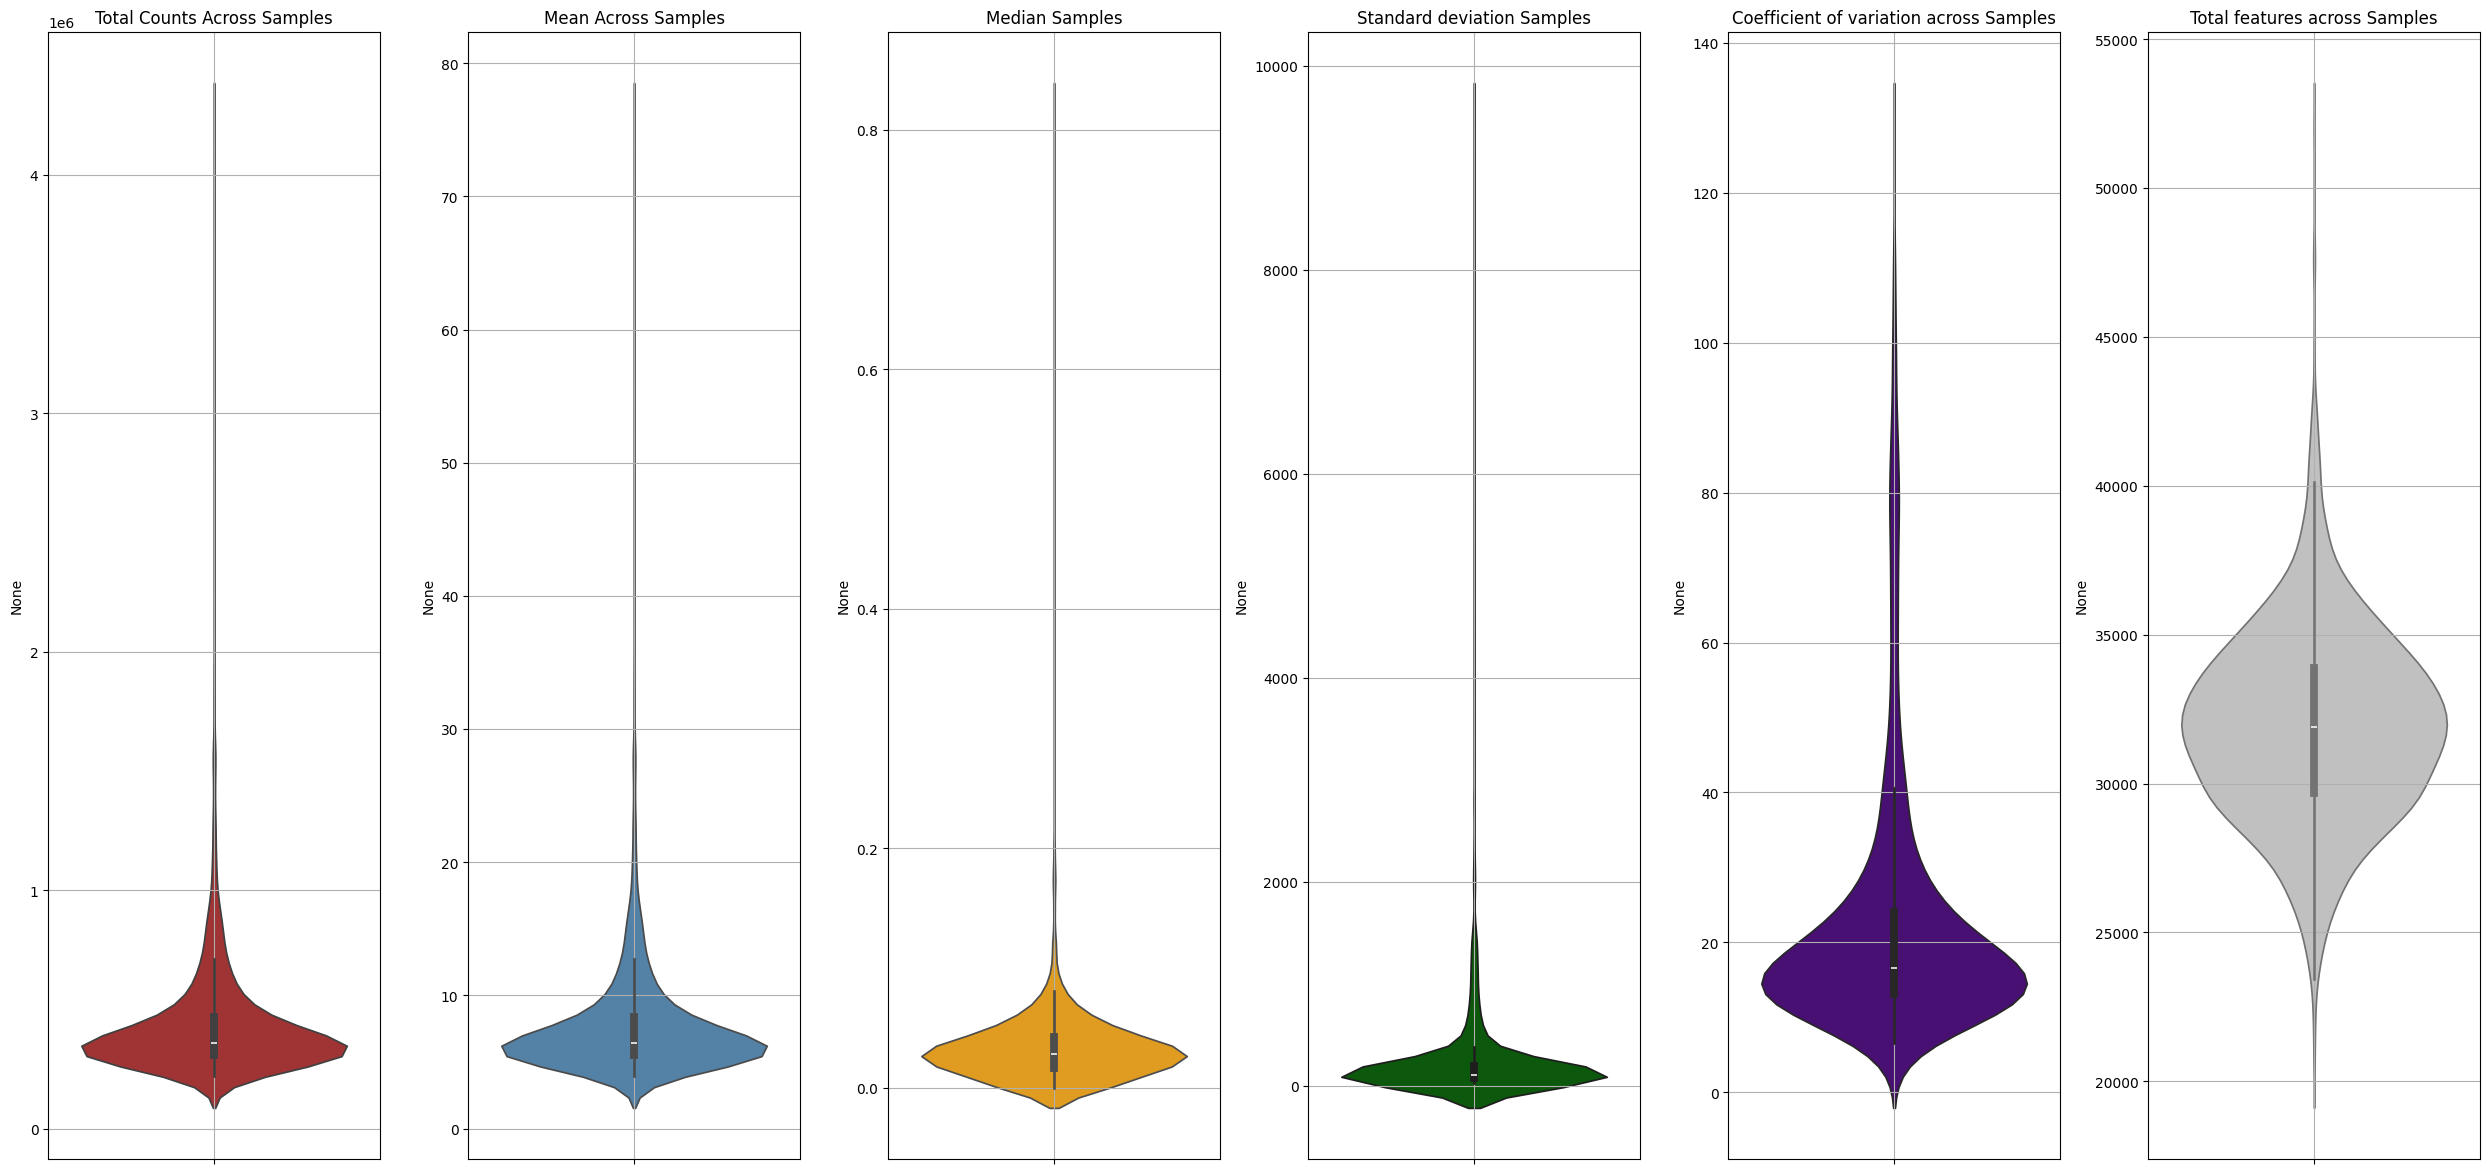

Max_total_count (4252383.305870472) - Min_total_count (221125.10852432536) = 4031258.197346147
Max_mean_count (76.13799763424956) - Min_mean_count (3.9591969440891903) = 72.17880069016037
Max_median_count (0.822531542195) - Min_median_count (0.0) = 0.822531542195
Max_std (9591.48296576888) - Min_std (26.982627367040084) = 9564.50033840184
Max CV (125.97498310691445) - Min CV (6.617365329042044) = 119.3576177778724
Max feature count  (51945) - Min feature count (20701) = 31244


In [14]:
#Violin metrics across sample 
plot_violin_metrics(mRNA_data,axis = 0)

In [15]:
corr_matrix_micro = mRNA_data.corr()

In [16]:
print('-----mRNA data matrix-----')
print('Minimum correlation between samples:',corr_matrix_micro.describe().loc['min'].min())
print('Minimum mean correlation between samples:',corr_matrix_micro.describe().loc['mean'].min())

-----mRNA data matrix-----
Minimum correlation between samples: 0.0010921323216801276
Minimum mean correlation between samples: 0.06338340175719509


In [17]:
# Extracting a random sample of mutated and non mutated data
random_samples_mut_100 = np.random.choice(mutated_samples,size = 100)
random_samples_non_mut_100 = np.random.choice(non_mutated_samples,size = 100)

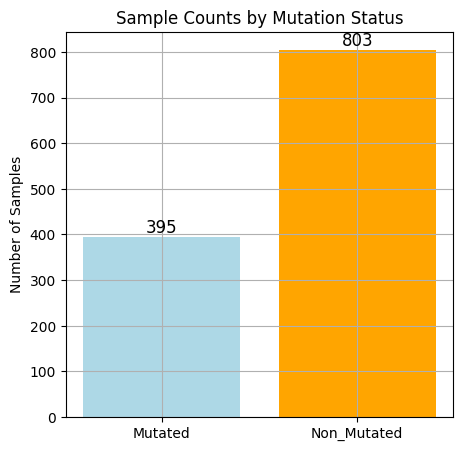

In [18]:
# See mutated distribution
counts = [len(mutated_samples), len(non_mutated_samples)]

plt.figure(figsize = (5,5))
plt.bar(x=['Mutated', 'Non_Mutated'], height=counts, 
                            color=['lightblue', 'orange'])

# Add text labels on top of each bar
for i, count in enumerate(counts):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=12)

plt.grid(True)
plt.ylabel("Number of Samples")
plt.title("Sample Counts by Mutation Status")
plt.show()

In the following section, we visualise the correlation in 100 randomly sampled mutated and non-mutated samples to determine whether it is strong enough to be visible. Specifically, we are interested in seeing if the correlation values obtained when considering a single class (mutated or non-mutated) differ significantly from those computed on the entire dataset.

Number of samples plotted: (100, 100)


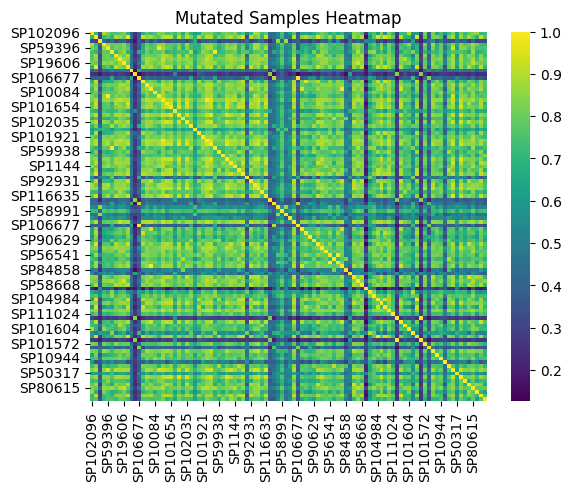

In [19]:
heatmap_plot(title = 'Mutated Samples Heatmap',data=mRNA_data,samples = random_samples_mut_100)

Number of samples plotted: (100, 100)


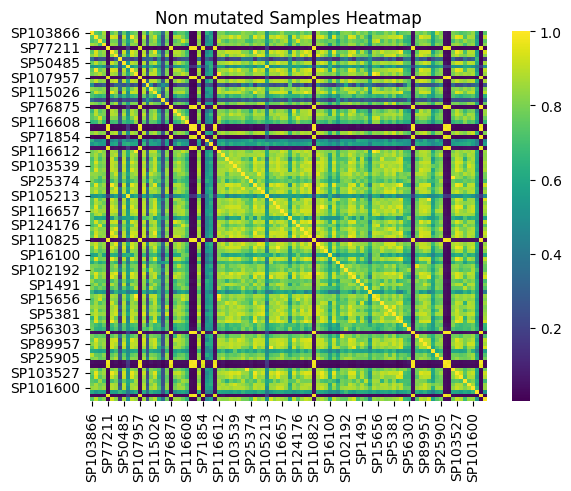

In [20]:
heatmap_plot(title = 'Non mutated Samples Heatmap',data=mRNA_data,samples = random_samples_non_mut_100)

In [21]:
#-----Mutated samples-----------
print('----Mutated Samples-----')
print('1) Minimum correlation between samples:',mRNA_data.loc[:, mutated_samples].corr().describe().loc['min'].min())
print('2) Minimum mean correlation between samples:',mRNA_data.loc[:, mutated_samples].corr().describe().loc['mean'].min())
#----- Non Mutated samples-----------
print('----Non Mutated Samples-------')
print('1) Minimum correlation between samples:',mRNA_data.loc[:, non_mutated_samples].corr().describe().loc['min'].min())
print('2) Minimum mean correlation between samples:',mRNA_data.loc[:, non_mutated_samples].corr().describe().loc['mean'].min())

----Mutated Samples-----
1) Minimum correlation between samples: 0.005190935018197021
2) Minimum mean correlation between samples: 0.03171332054278077
----Non Mutated Samples-------
1) Minimum correlation between samples: 0.0010921323216801276
2) Minimum mean correlation between samples: 0.08570717406457547


From this analysis alone, we can see that the mutated samples tend to be more highly correlated with each other than the non-mutated samples.

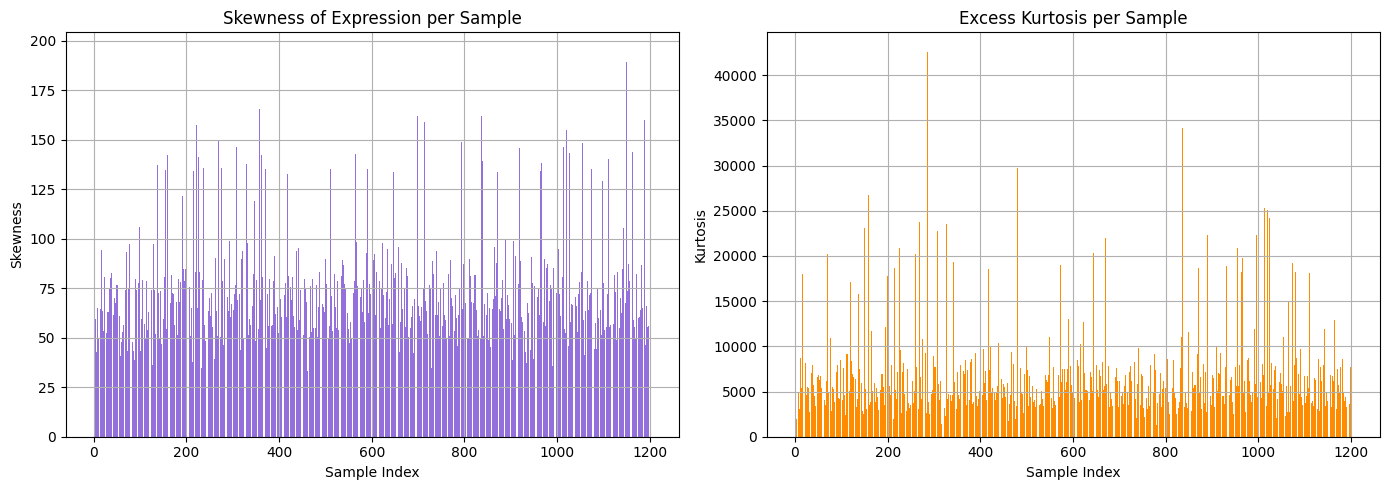

In [22]:
plot_skewness_kurtosis(data=mRNA_data,axis = 0)

The skewness and kurtosis measures are commonly used to assess the normality of a distribution. Skweness quantifies the symmetry of the data distribution, while kurtosis measures the thickness of the tails.

There are three types of skewness:

Zero:the skewness is zero when the distributiom is exactly normal;
Positive: this is known as the right skewed distribution, the right tail is longer and fatter than the left;
Negative: this is known as the left skewed distribution, the left tail is longer and fatter than the right.
It is computed as:


There are three types of kurtosis (scipy library compute excess kurtosis which is kurtosis - 3):

Mesokurtic(kurtosis = 3): perfect normal distribution;
Leptokurtic(kurtosis > 3): sharp peak, heavy tails;
Platykurtic(kurtosis < 3): flat peak, light tails;
It is computed as:

In our case, we have positive skewness and positive kurtosis.

## Gene analysis and filtering

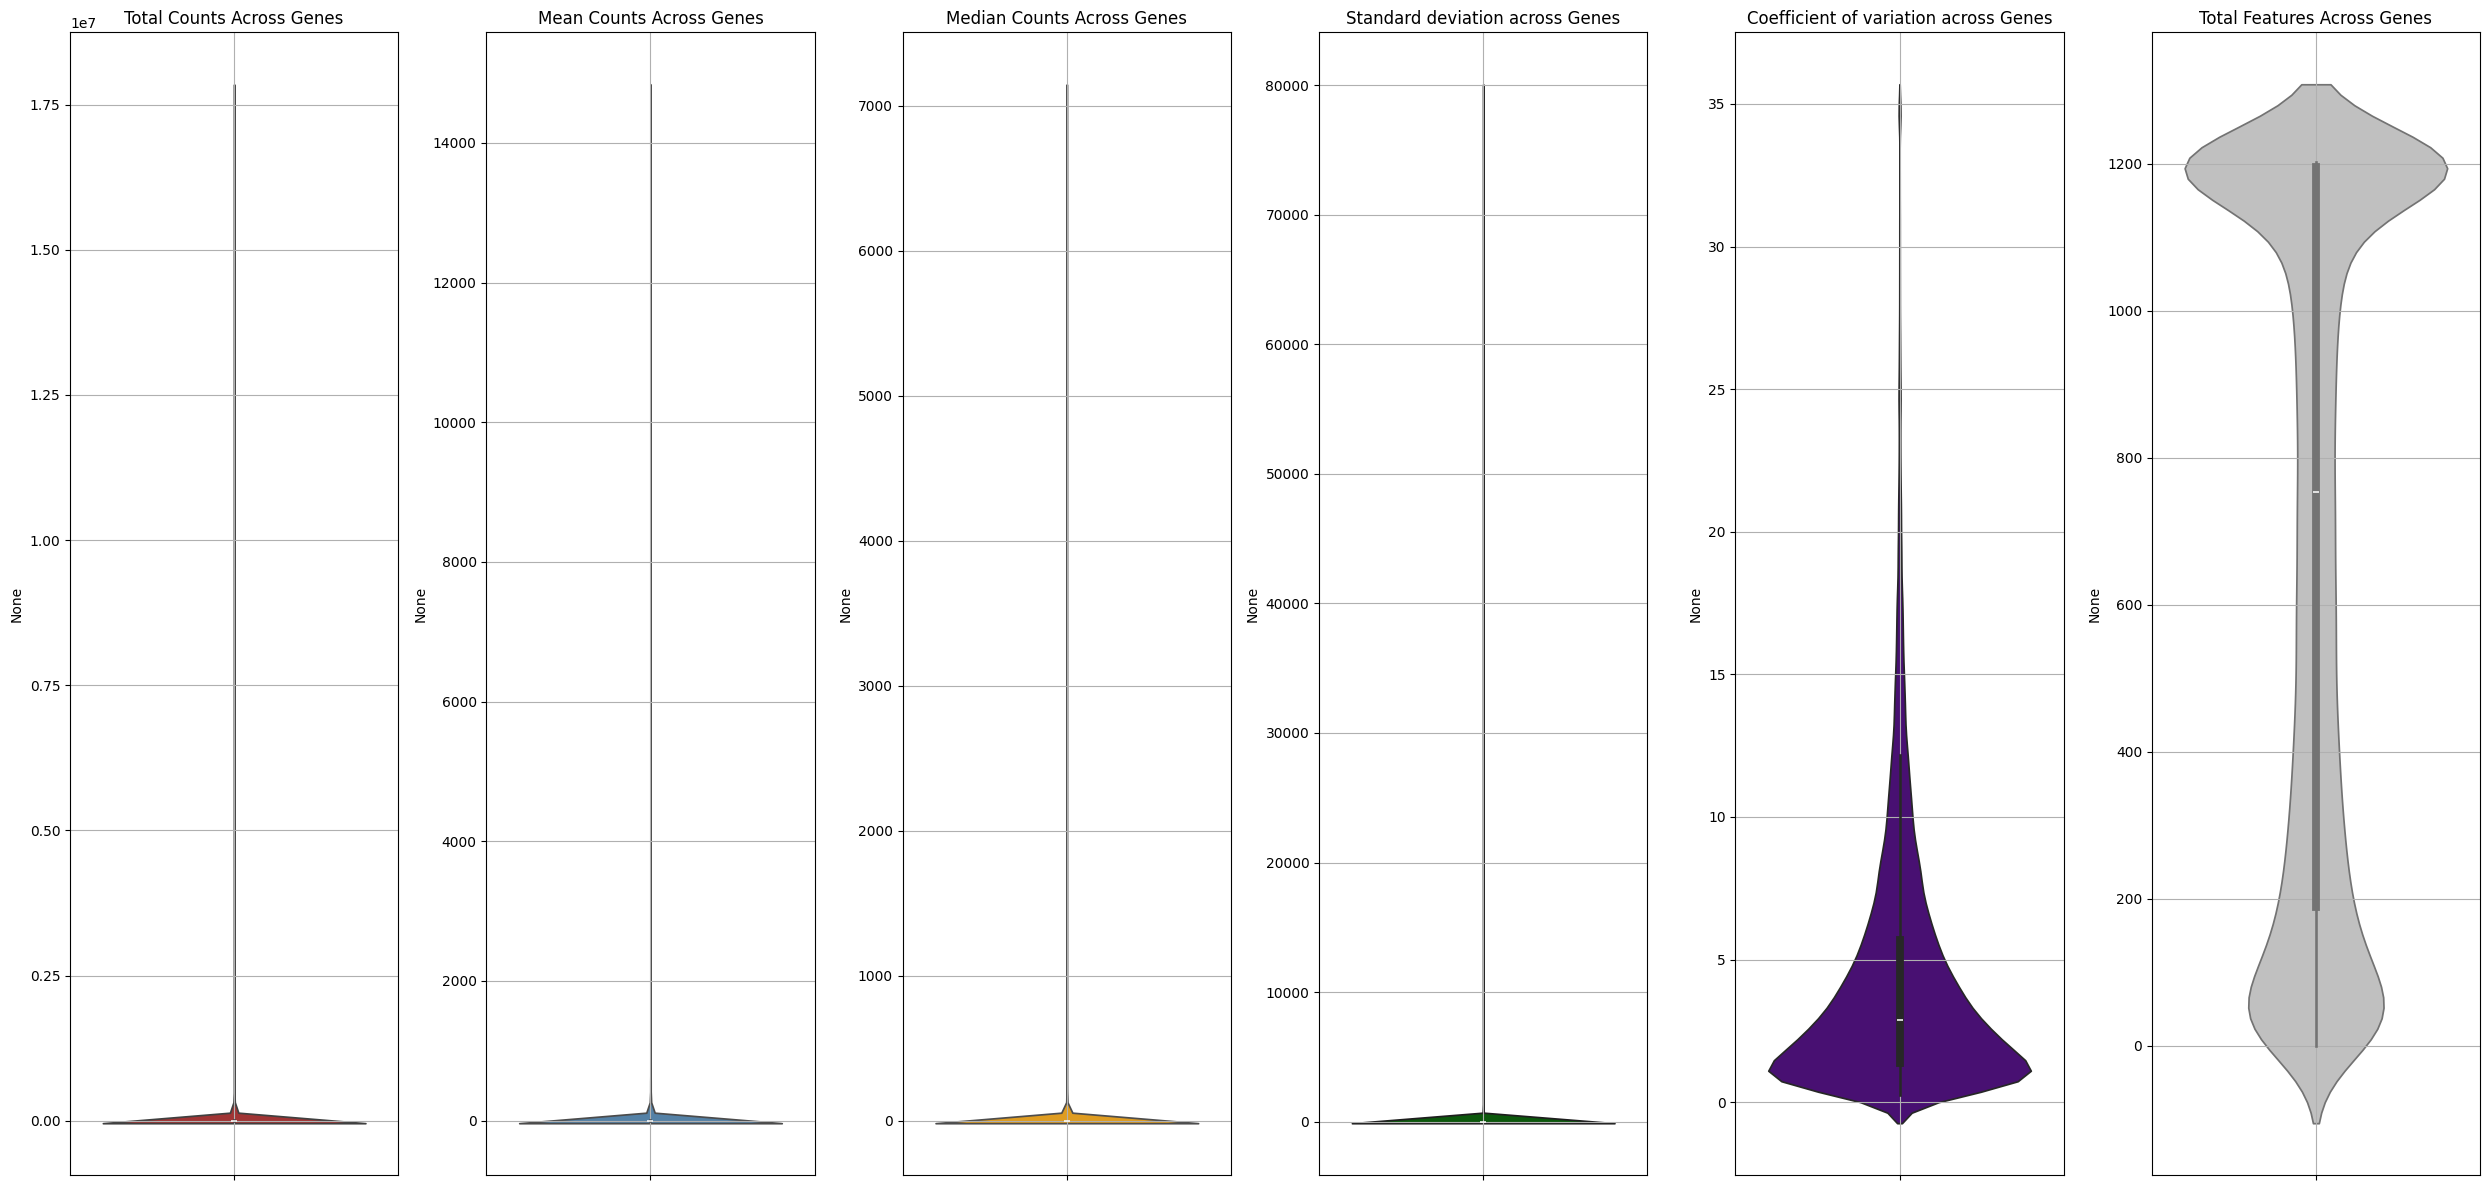

Max_total_count (17807169.3772896) - Min_total_count (0.0) = 17807169.3772896
Max_mean_count (14802.302059259851) - Min_mean_count (0.0) = 14802.302059259851
Max_median_count (7129.9439401) - Min_median_count (0.0) = 7129.9439401
Max std  (79947.29400430074) - Min std (0.0) = 79947.29400430074
Max cv  (34.68429039204927) - Min cv (0.2679567980680528) = 34.416333593981214
Max feature count  (1203) - Min feature count (0) = 1203


In [23]:
# Violin metrics per gene 
plot_violin_metrics(mRNA_data,axis = 1)

The coefficient of variation varies considerably between genes, suggesting that we should filter them by removing those with expression levels that are either too constant or too variable compared to the mean.

In [24]:
# Filter out genes with a coefficient of variation less than 5%
# If gene expression does not vary much compared to the mean, then it is probably less significant to our analysis.

cv_genes = mRNA_data.std(axis = 1)/mRNA_data.mean(axis = 1) 
genes_to_keep = cv_genes[(cv_genes > 0.05) & (cv_genes< 50)].index

# remove
mRNA_final = mRNA_data.loc[genes_to_keep]

We can now see if filtering has had a significant impact on the samples and genes.

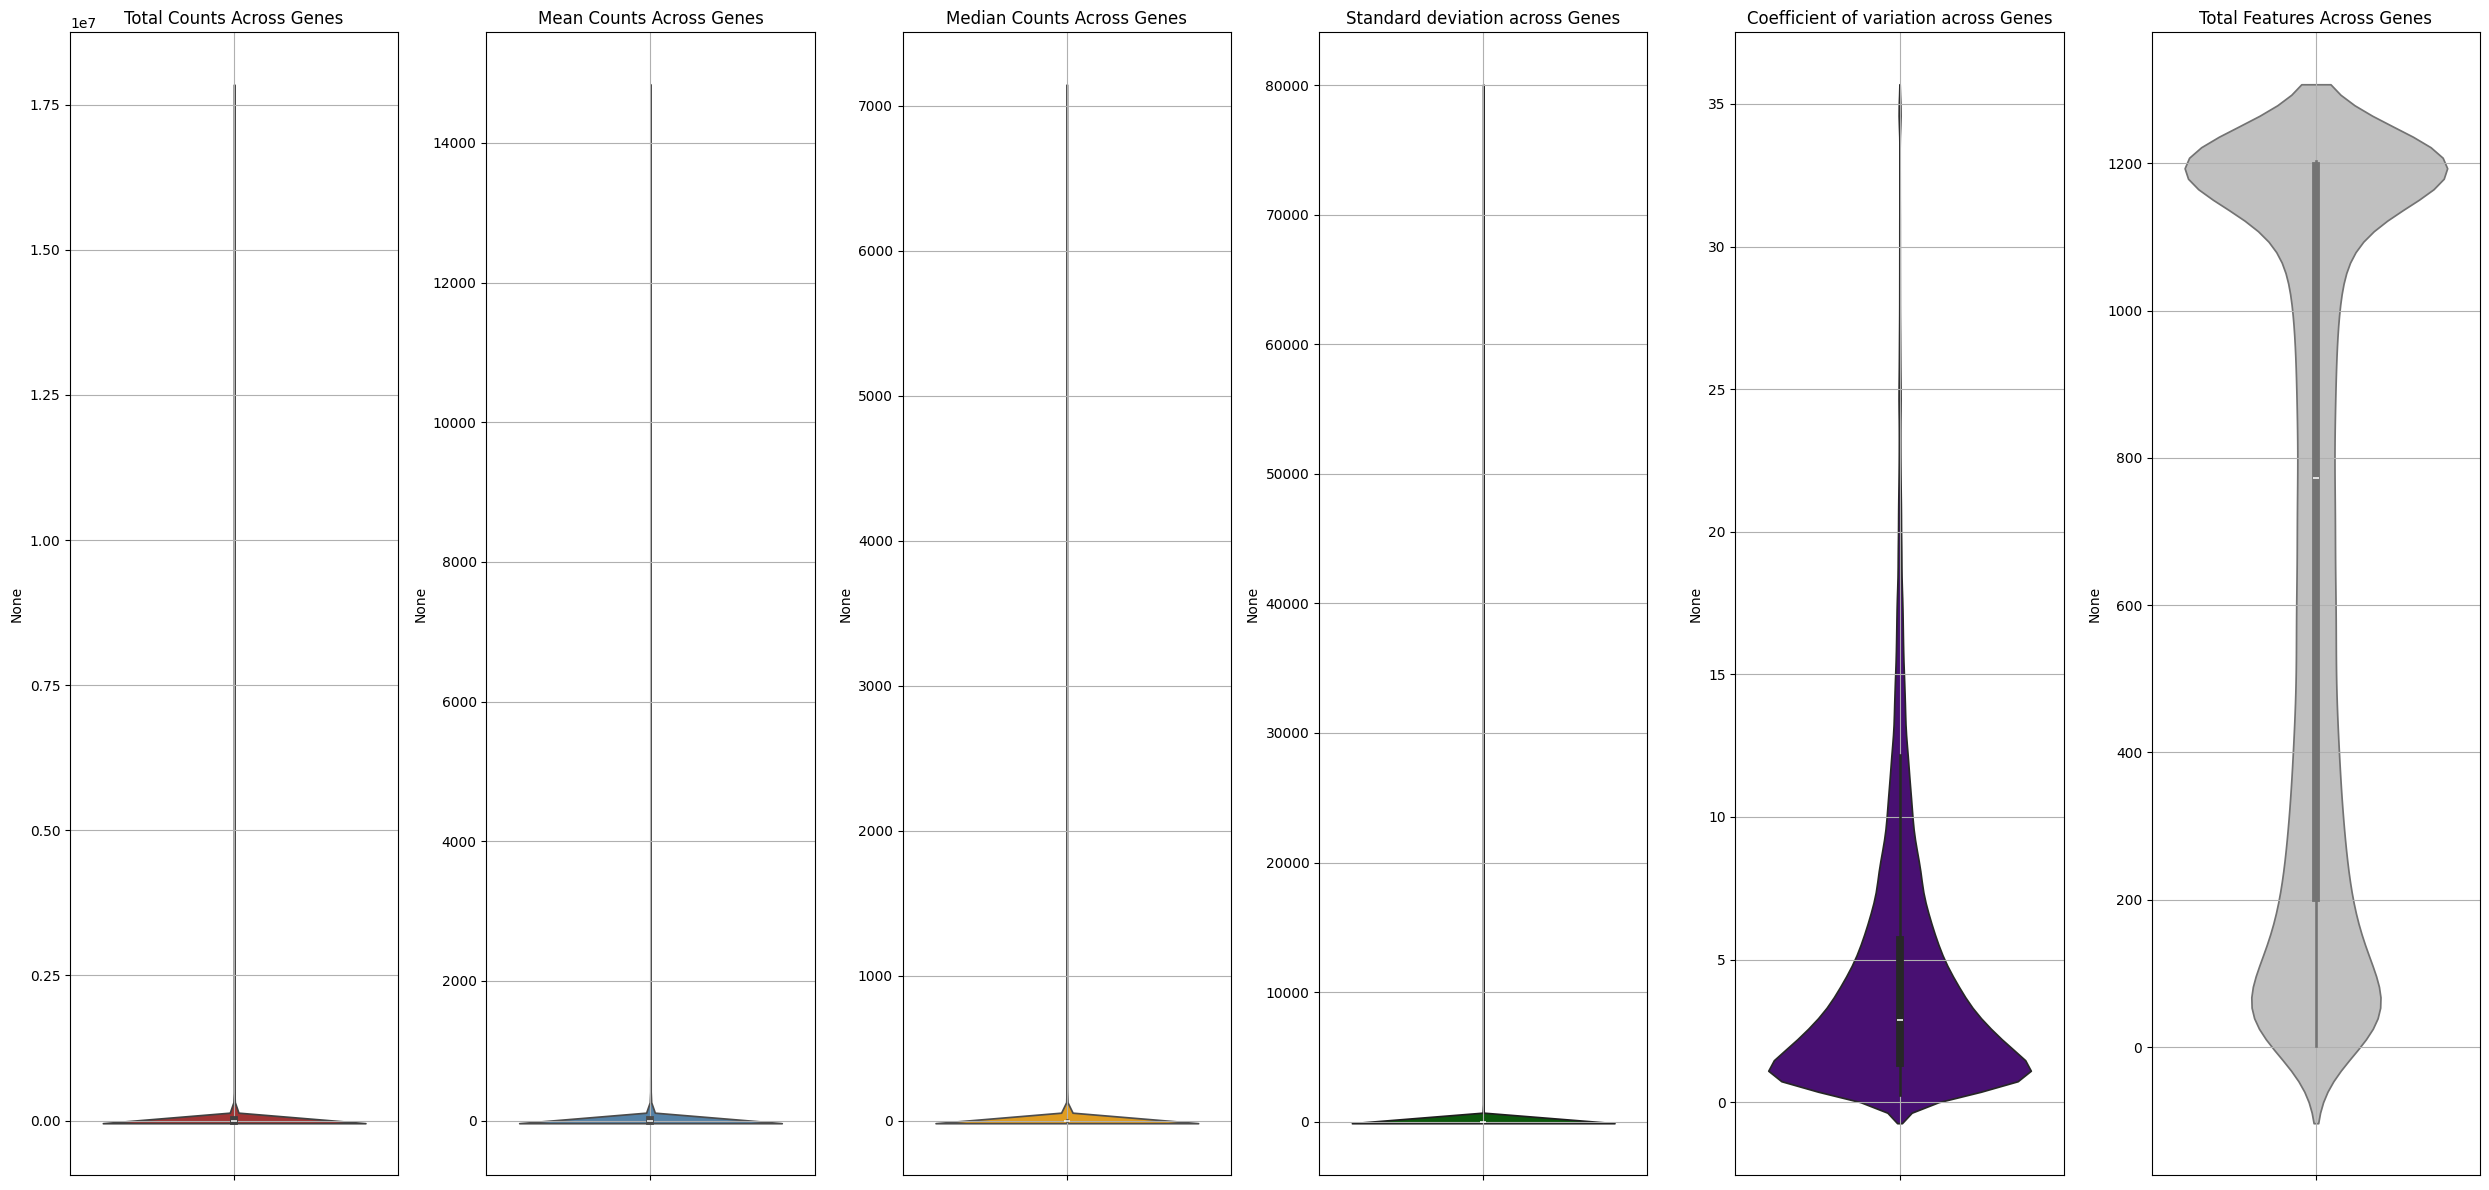

Max_total_count (17807169.3772896) - Min_total_count (0.00251949416467) = 17807169.374770105
Max_mean_count (14802.302059259851) - Min_mean_count (2.094342614023275e-06) = 14802.302057165509
Max_median_count (7129.9439401) - Min_median_count (0.0) = 7129.9439401
Max std  (79947.29400430074) - Min std (7.26407874052268e-05) = 79947.29393165995
Max cv  (34.68429039204927) - Min cv (0.2679567980680528) = 34.416333593981214
Max feature count  (1203) - Min feature count (1) = 1202


In [25]:
plot_violin_metrics(mRNA_final,axis = 1)

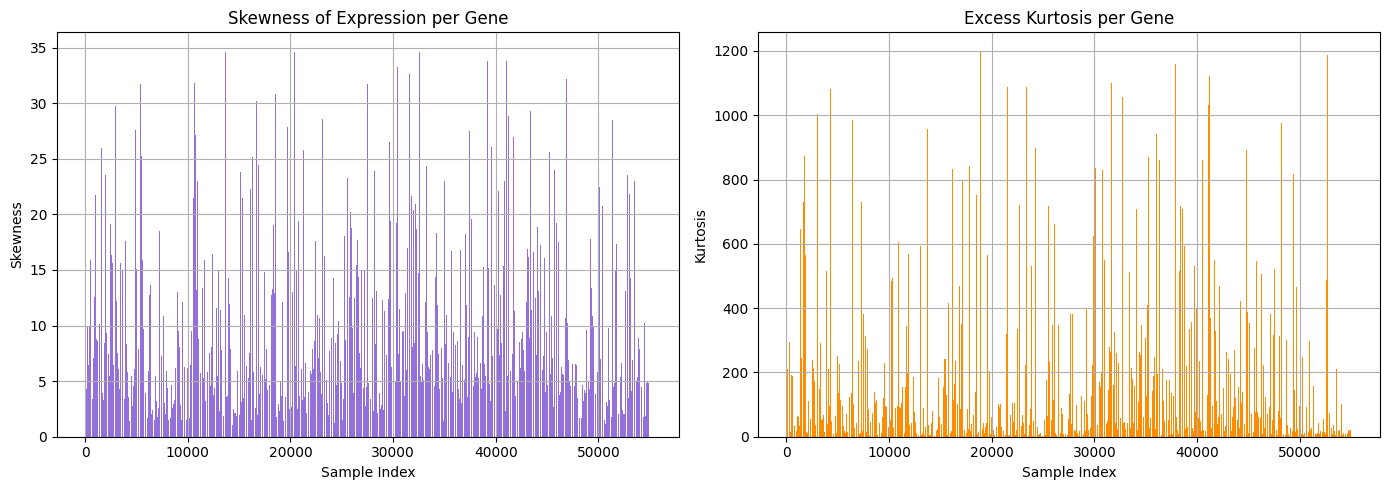

In [26]:
plot_skewness_kurtosis(mRNA_final,axis = 1)

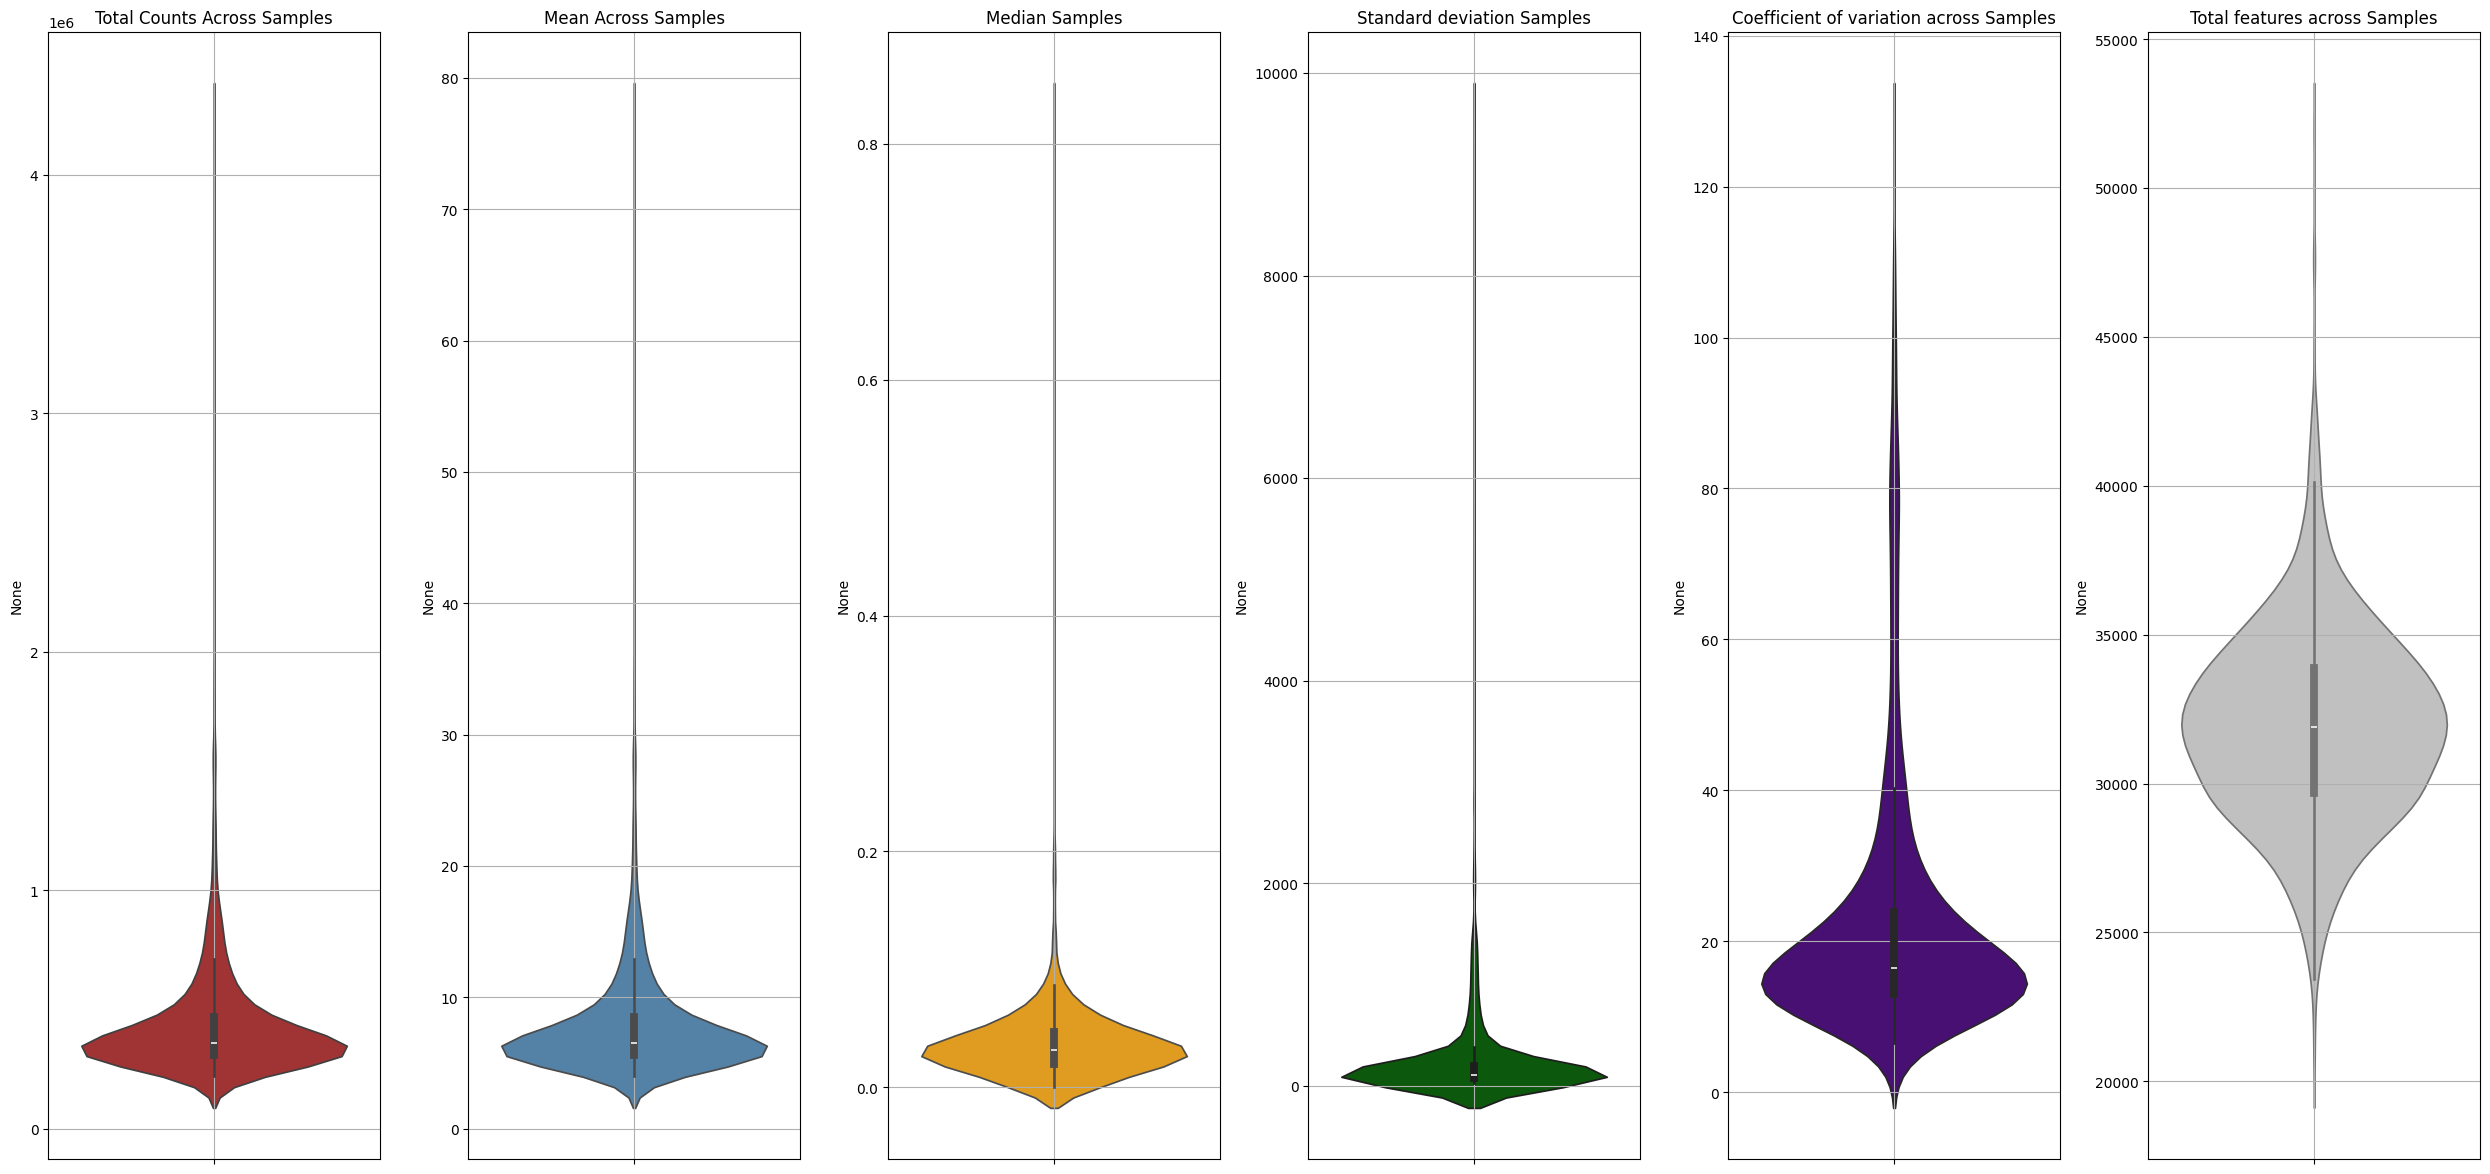

Max_total_count (4252383.305870472) - Min_total_count (221125.10852432533) = 4031258.197346147
Max_mean_count (77.20096049291007) - Min_mean_count (4.0144713068575095) = 73.18648918605255
Max_median_count (0.834583286403) - Min_median_count (0.0) = 0.834583286403
Max_std (9658.201221723568) - Min_std (27.165998540659476) = 9631.03522318291
Max CV (125.1046769374139) - Min CV (6.57060403983934) = 118.53407289757456
Max feature count  (51945) - Min feature count (20701) = 31244


In [27]:
# See how it affected the samples
plot_violin_metrics(mRNA_final,axis = 0)

## Dimensionality reduction

In this section of the notebook, we apply dimensionality reduction techniques to visualise and determine whether there is good separation between mutated and non-mutated samples.

In [28]:
mRNA_data_all = mRNA_final[mutated_samples.tolist() + non_mutated_samples.tolist()]

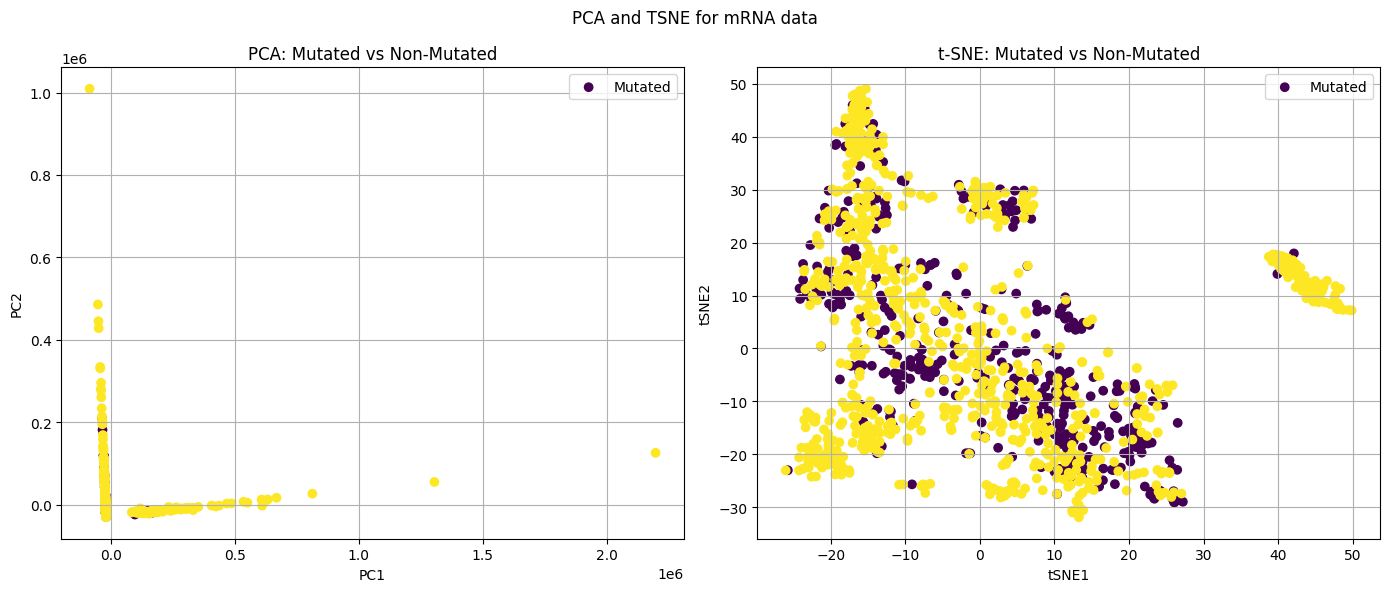

In [29]:
plot_PCA_tsne(mRNA_data_all,mutated_samples,non_mutated_samples,'PCA and TSNE for mRNA data')

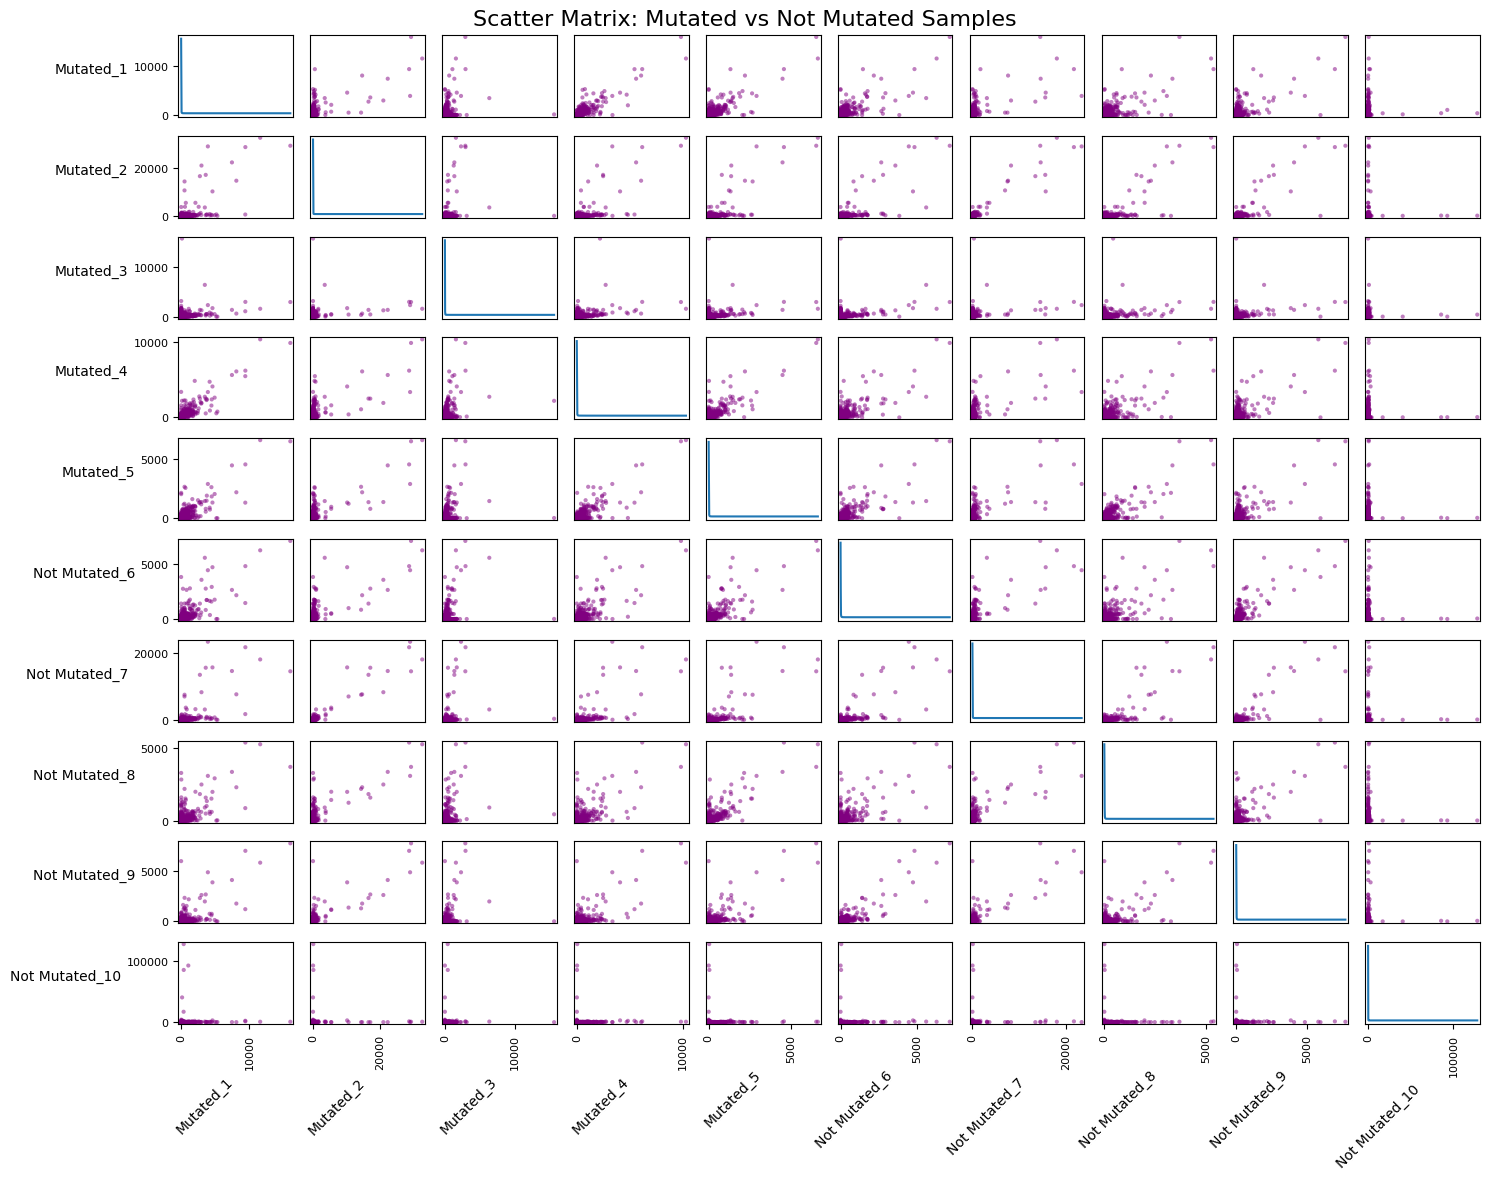

In [30]:
sample_ids = random_samples_mut_100[:5].tolist() + random_samples_non_mut_100[:5].tolist()
sample_mut_non_mut = mRNA_data.loc[:, sample_ids]

# Rename columns to clearer labels
new_labels = ['Mutated'] * 5 + ['Not Mutated'] * 5
sample_mut_non_mut.columns = [f"{label}_{i+1}" for i, label in enumerate(new_labels)]
axes = scatter_matrix(sample_mut_non_mut, diagonal='kde', figsize=(15, 12), color='purple')

# Rotate x and y axis labels for all subplots
for ax in axes.ravel():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), rotation=45, ha='right')
        ax.set_ylabel(ax.get_ylabel(), rotation=0, ha='right')

plt.suptitle("Scatter Matrix: Mutated vs Not Mutated Samples", fontsize=16)
plt.tight_layout()
plt.show()

In [31]:
X = mRNA_data 
y = merged_mutation.Variant_Type

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X.T, y,
    test_size=0.2,         
    stratify=y,            
    random_state=42        
)
X_train = X_train.T 
X_test = X_test.T

In [34]:
print("Train:",X_train.shape)
print("Test:",X_test.shape)
print("Train:",y_train.shape)
print("Test:",y_test.shape)

Train: (55851, 962)
Test: (55851, 241)
Train: (962,)
Test: (241,)


In [35]:
# Save all the dataframes and arrays
X_train.to_csv('../DATA/tcga/X_train.csv')
X_test.to_csv('../DATA/tcga/X_test.csv')
y_train.to_csv('../DATA/tcga/y_train.csv')
y_test.to_csv('../DATA/tcga/y_test.csv')
